# Bước 4: Thống kê Dataset

Chạy từ thư mục gốc project: `d:/TaiLieuHocTap/Extraction ID Card`

Output:
- `data/interim/dataset_statistics.json`
- `data/interim/dataset_statistics_plots/` (5 biểu đồ)

In [1]:
import json
import os
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm

PROJECT_DIR = Path("d:/TaiLieuHocTap/Extraction ID Card")
os.chdir(PROJECT_DIR)

DATA_DIR = Path("data/cccd.v1i.coco")
INTERIM_DIR = Path("data/interim")
PLOTS_DIR = INTERIM_DIR / "dataset_statistics_plots"
SPLITS = ["train", "valid", "test"]

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## Load dữ liệu

In [3]:
all_images = []
all_anns = []
categories = {}

for split in SPLITS:
    with open(DATA_DIR / split / "_annotations.coco.json", encoding="utf-8") as f:
        coco = json.load(f)

    if not categories:
        categories = {c["id"]: c["name"] for c in coco["categories"]}

    img_id_to_info = {img["id"]: img for img in coco["images"]}
    for img in coco["images"]:
        img["split"] = split
        img["full_path"] = str(DATA_DIR / split / img["file_name"])
        all_images.append(img)

    for ann in coco["annotations"]:
        ann["split"] = split
        img_info = img_id_to_info[ann["image_id"]]
        ann["img_width"] = img_info["width"]
        ann["img_height"] = img_info["height"]
        ann["img_full_path"] = str(DATA_DIR / split / img_info["file_name"])
        all_anns.append(ann)

print(f"{len(all_images)} ảnh | {len(all_anns)} annotations | {len(categories)} categories")
print(f"Categories: {categories}")
print(f"Split data: { {s: sum(1 for img in all_images if img['split'] == s) for s in SPLITS} }")

4399 ảnh | 30854 annotations | 8 categories
Categories: {0: 'cccd', 1: 'address', 2: 'birth', 3: 'card', 4: 'id', 5: 'name', 6: 'origin', 7: 'title'}
Split data: {'train': 3846, 'valid': 366, 'test': 187}


## 1. Phân bố kích thước ảnh

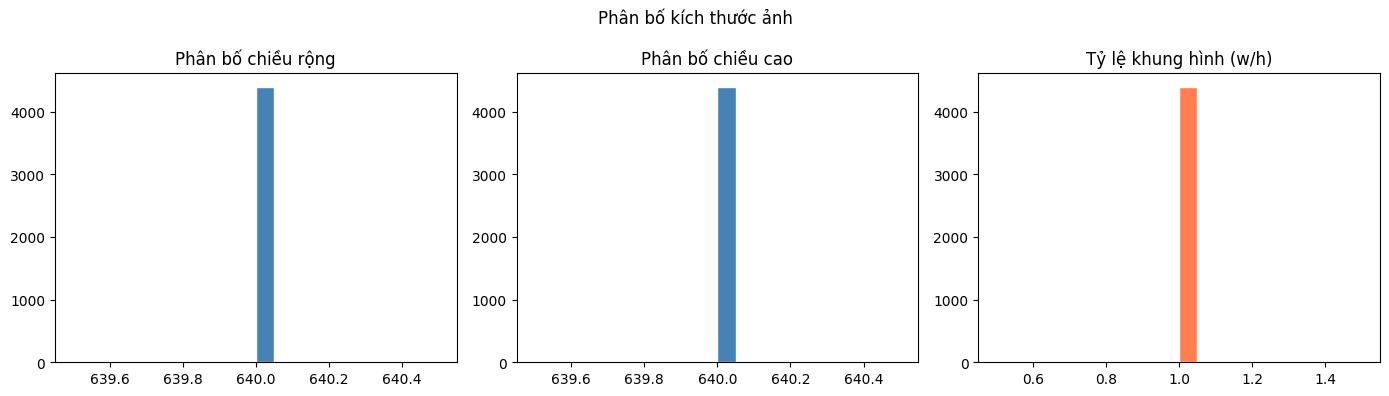

In [6]:
widths = [img["width"] for img in all_images]
heights = [img["height"] for img in all_images]
aspects = [w / h for w, h in zip(widths, heights)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(widths, bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Phân bố chiều rộng")
axes[1].hist(heights, bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Phân bố chiều cao")
axes[2].hist(aspects, bins=20, color="coral", edgecolor="white")
axes[2].set_title("Tỷ lệ khung hình (w/h)")
fig.suptitle("Phân bố kích thước ảnh")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "01_image_sizes.png", dpi=120, bbox_inches="tight")
plt.show()


## 2. Phân bố số annotation per image

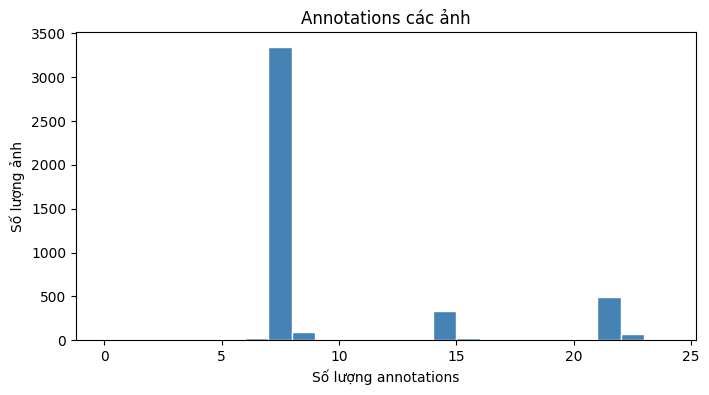

In [8]:
img_id_count = Counter(ann["image_id"] for ann in all_anns)
counts = [img_id_count.get(img["id"], 0) for img in all_images]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(counts, bins=range(0, max(counts) + 2), color="steelblue", edgecolor="white")
ax.set_title("Annotations các ảnh")
ax.set_xlabel("Số lượng annotations")
ax.set_ylabel("Số lượng ảnh")
fig.savefig(PLOTS_DIR / "02_annotations_per_image.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Phân bố bbox per class (size và vị trí)

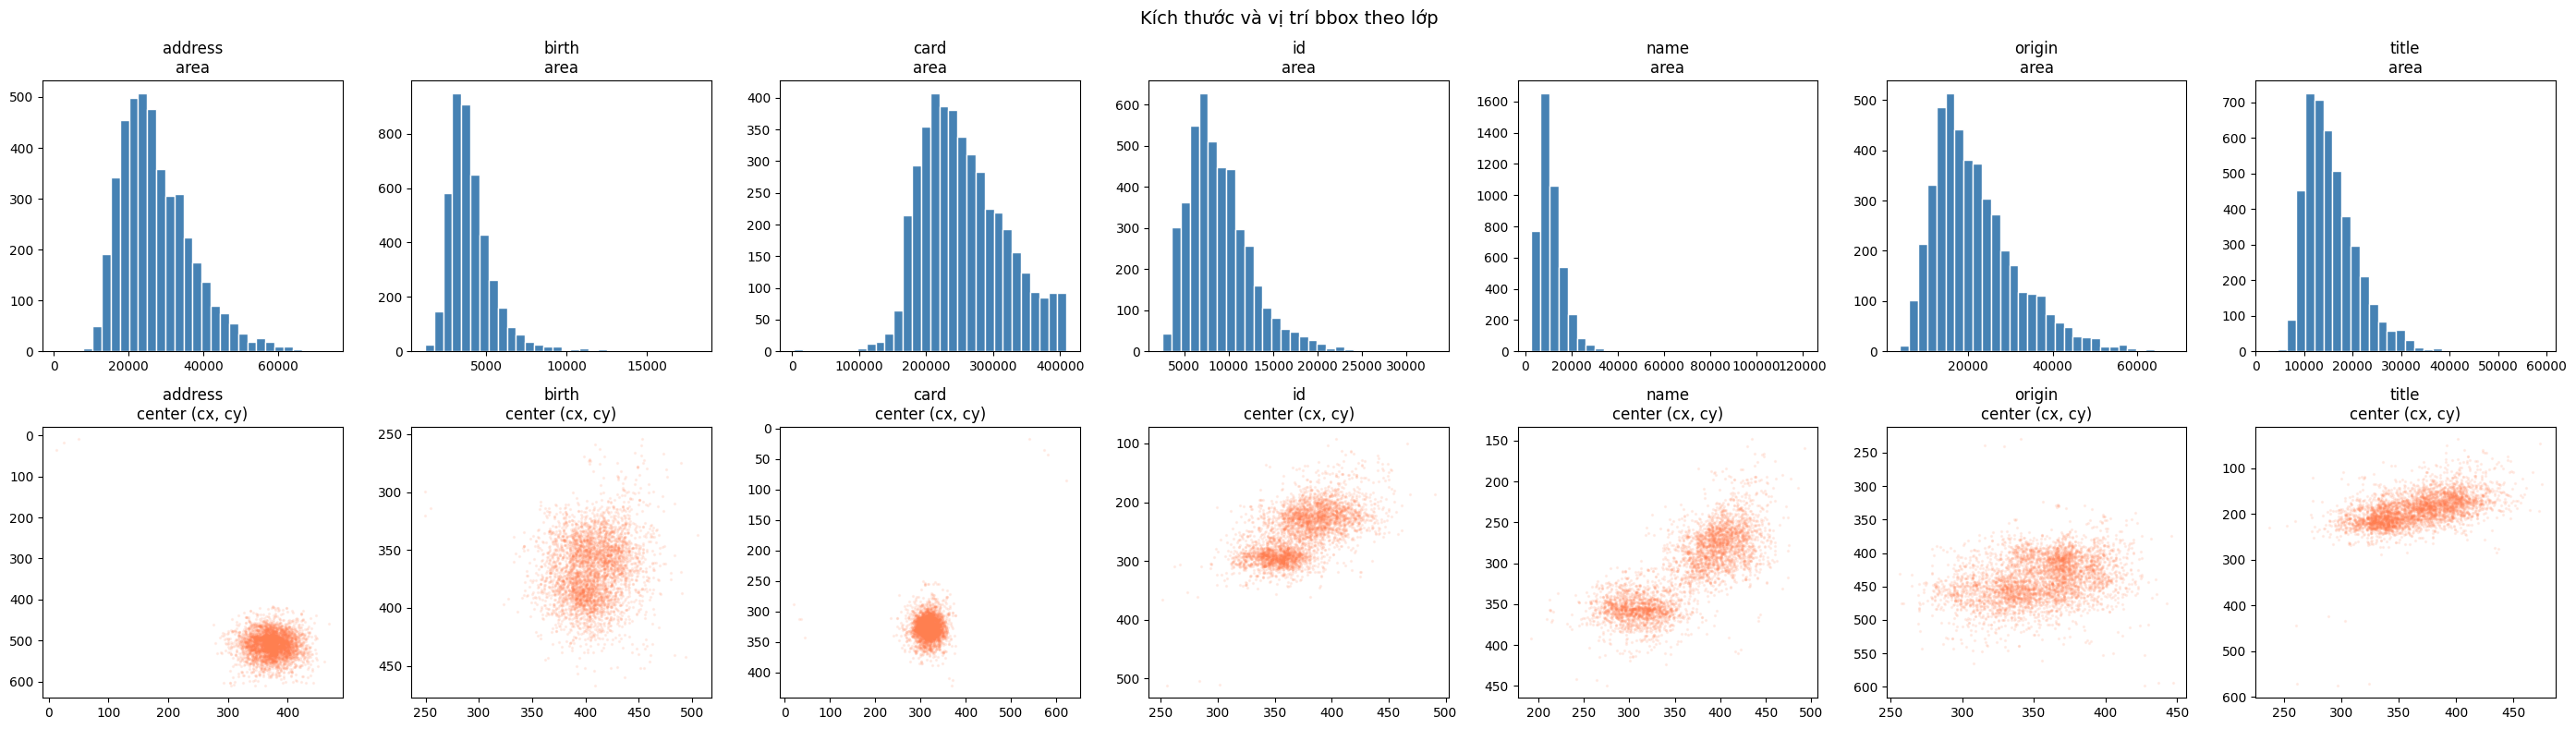

address   : 4383 bbox | area mean=27467 std=9611
birth     : 4403 bbox | area mean=4058 std=1514
card      : 4382 bbox | area mean=256659 std=62543
id        : 4399 bbox | area mean=8941 std=3604
name      : 4428 bbox | area mean=11267 std=6300
origin    : 4459 bbox | area mean=21751 std=9929
title     : 4400 bbox | area mean=15733 std=5525


In [10]:
by_class = defaultdict(list)
for ann in all_anns:
    cls = categories.get(ann["category_id"], "?")
    if cls == "cccd":
        continue
    x, y, w, h = ann["bbox"]
    by_class[cls].append({"w": w, "h": h, "area": w * h, "cx": x + w / 2, "cy": y + h / 2})

class_names = sorted(by_class.keys())
fig, axes = plt.subplots(2, len(class_names), figsize=(4 * len(class_names), 8))

bbox_stats = {}
for col, cls in enumerate(class_names):
    data = by_class[cls]
    areas = [d["area"] for d in data]
    cxs = [d["cx"] for d in data]
    cys = [d["cy"] for d in data]

    axes[0][col].hist(areas, bins=30, color="steelblue", edgecolor="white")
    axes[0][col].set_title(f"{cls}\narea")
    axes[1][col].scatter(cxs, cys, alpha=0.1, s=2, color="coral")
    axes[1][col].set_title(f"{cls}\ncenter (cx, cy)")
    axes[1][col].invert_yaxis()

    bbox_stats[cls] = {
        "count": len(data),
        "area_mean": float(np.mean(areas)),
        "area_std": float(np.std(areas)),
    }

fig.suptitle("Kích thước và vị trí bbox theo lớp", fontsize=14)
plt.tight_layout()
fig.savefig(PLOTS_DIR / "03_bbox_per_class.png", dpi=120, bbox_inches="tight")
plt.show()

for cls, s in bbox_stats.items():
    print(f"{cls:10s}: {s['count']} bbox | area mean={s['area_mean']:.0f} std={s['area_std']:.0f}")

## 4. Co-occurrence matrix

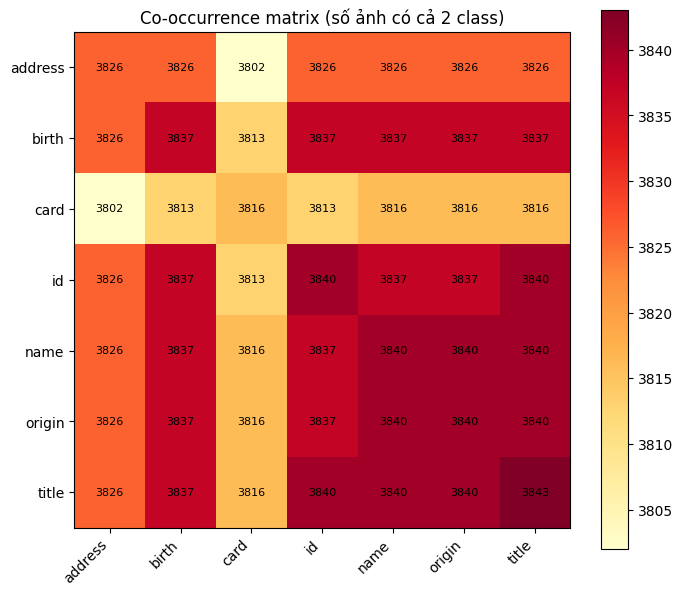

In [12]:
class_names = sorted(set(categories.values()) - {"cccd"})
name_to_idx = {n: i for i, n in enumerate(class_names)}
n = len(class_names)
matrix = np.zeros((n, n), dtype=int)

by_img = defaultdict(set)
for ann in all_anns:
    cls = categories.get(ann["category_id"], "?")
    if cls != "cccd":
        by_img[ann["image_id"]].add(cls)

for classes in by_img.values():
    cls_list = list(classes)
    for i in range(len(cls_list)):
        for j in range(len(cls_list)):
            if cls_list[i] in name_to_idx and cls_list[j] in name_to_idx:
                matrix[name_to_idx[cls_list[i]]][name_to_idx[cls_list[j]]] += 1

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(matrix, cmap="YlOrRd")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
for i in range(n):
    for j in range(n):
        ax.text(j, i, str(matrix[i, j]), ha="center", va="center", fontsize=8)
fig.colorbar(im)
ax.set_title("Co-occurrence matrix (số ảnh có cả 2 class)")
fig.savefig(PLOTS_DIR / "04_cooccurrence.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Brightness & Contrast

Đọc ảnh:   0%|          | 0/880 [00:00<?, ?it/s]

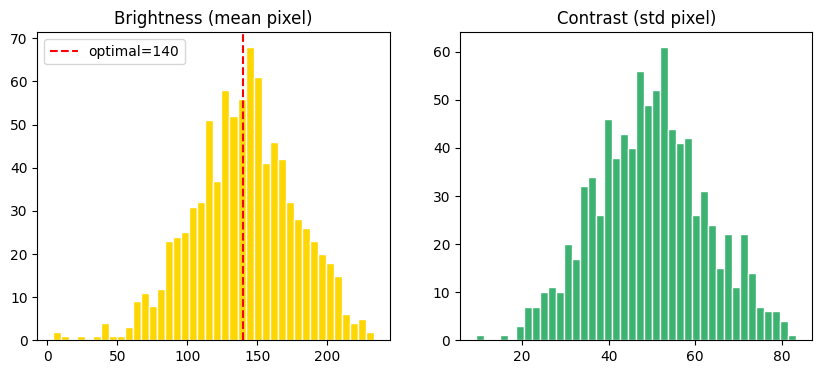

Brightness: mean=140.3, std=36.6
Contrast:   mean=49.6, std=12.7
Sample size: 880 ảnh


In [13]:
brightness_vals = []
contrast_vals = []
sample = all_images[::5]  # lấy 1/5 để nhanh

for img_info in tqdm(sample, desc="Đọc ảnh"):
    img = cv2.imread(img_info["full_path"], cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    brightness_vals.append(float(np.mean(img)))
    contrast_vals.append(float(np.std(img)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(brightness_vals, bins=40, color="gold", edgecolor="white")
axes[0].set_title("Brightness (mean pixel)")
axes[0].axvline(140, color="red", linestyle="--", label="optimal=140")
axes[0].legend()
axes[1].hist(contrast_vals, bins=40, color="mediumseagreen", edgecolor="white")
axes[1].set_title("Contrast (std pixel)")
fig.savefig(PLOTS_DIR / "05_brightness_contrast.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Brightness: mean={np.mean(brightness_vals):.1f}, std={np.std(brightness_vals):.1f}")
print(f"Contrast:   mean={np.mean(contrast_vals):.1f}, std={np.std(contrast_vals):.1f}")
print(f"Sample size: {len(brightness_vals)} ảnh")

## Lưu JSON tổng hợp

In [14]:
stats = {
    "total_images": len(all_images),
    "total_annotations": len(all_anns),
    "categories": categories,
    "split_counts": {s: sum(1 for img in all_images if img["split"] == s) for s in SPLITS},
    "image_sizes": {
        "width": {"mean": float(np.mean(widths)), "std": float(np.std(widths)),
                  "min": int(np.min(widths)), "max": int(np.max(widths))},
        "height": {"mean": float(np.mean(heights)), "std": float(np.std(heights)),
                   "min": int(np.min(heights)), "max": int(np.max(heights))},
        "aspect_ratio": {"mean": float(np.mean(aspects)), "std": float(np.std(aspects))},
    },
    "annotations_per_image": {
        "mean": float(np.mean(counts)), "std": float(np.std(counts)),
        "min": int(np.min(counts)), "max": int(np.max(counts)),
        "images_with_0": int(sum(1 for c in counts if c == 0)),
    },
    "bbox_per_class": bbox_stats,
    "brightness_contrast": {
        "brightness": {"mean": float(np.mean(brightness_vals)), "std": float(np.std(brightness_vals))},
        "contrast": {"mean": float(np.mean(contrast_vals)), "std": float(np.std(contrast_vals))},
        "sample_size": len(brightness_vals),
    },
}

out_json = INTERIM_DIR / "dataset_statistics.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(stats, f, ensure_ascii=False, indent=2)

print(f"Saved: {out_json}")
print(f"Plots: {PLOTS_DIR}/")

Saved: data\interim\dataset_statistics.json
Plots: data\interim\dataset_statistics_plots/
